In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional SQL tools
import duckdb
from pandasql import sqldf

sns.set(style="whitegrid")
%matplotlib inline

# Load data
df = pd.read_csv('KaggleV2-May-2016.csv')
print(df.shape)          # (110527, 14)
print(df.info())
df.head(3)

(110527, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB
None


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No


In [8]:
# Rename columns for ease
df = df.rename(columns={
    'PatientId': 'patient_id',
    'AppointmentID': 'appointment_id',
    'Gender': 'gender',
    'ScheduledDay': 'scheduled_day',
    'AppointmentDay': 'appointment_day',
    'Age': 'age',
    'Neighbourhood': 'neighbourhood',
    'Scholarship': 'scholarship',
    'Hipertension': 'hypertension',
    'Diabetes': 'diabetes',
    'Alcoholism': 'alcoholism',
    'Handcap': 'handicap',
    'SMS_received': 'sms_received',
    'No-show': 'no_show'
})

# Convert dates (remove time from appointment_day – it's midnight)
df['scheduled_day']   = pd.to_datetime(df['scheduled_day'])
df['appointment_day'] = pd.to_datetime(df['appointment_day'])

# Create useful features
df['waiting_days'] = (df['appointment_day'] - df['scheduled_day']).dt.days
df['waiting_days'] = df['waiting_days'].clip(lower=0)  # fix negative values (~few cases)

df['hour_scheduled'] = df['scheduled_day'].dt.hour
df['day_of_week']    = df['appointment_day'].dt.day_name()
df['is_weekend']     = df['appointment_day'].dt.weekday >= 5

# Fix age anomalies
df = df[(df['age'] >= 0) & (df['age'] <= 115)]  # remove ~5 invalid ages

# Map target to numeric
df['no_show'] = df['no_show'].map({'Yes': 1, 'No': 0})

# Check class balance
print(df['no_show'].value_counts(normalize=True))  # ~80% show, 20% no-show → mild imbalance

no_show
0    0.798066
1    0.201934
Name: proportion, dtype: float64


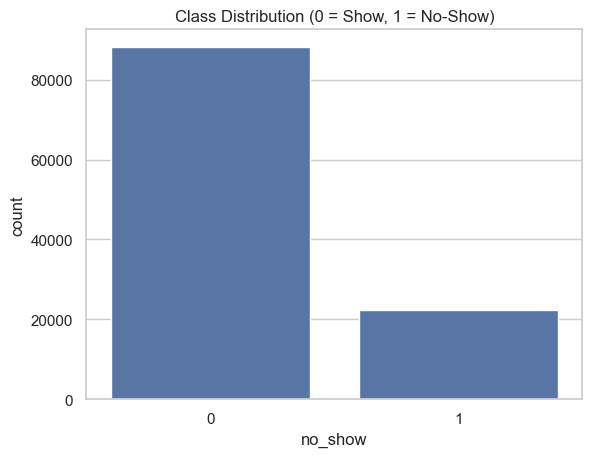

<Axes: >

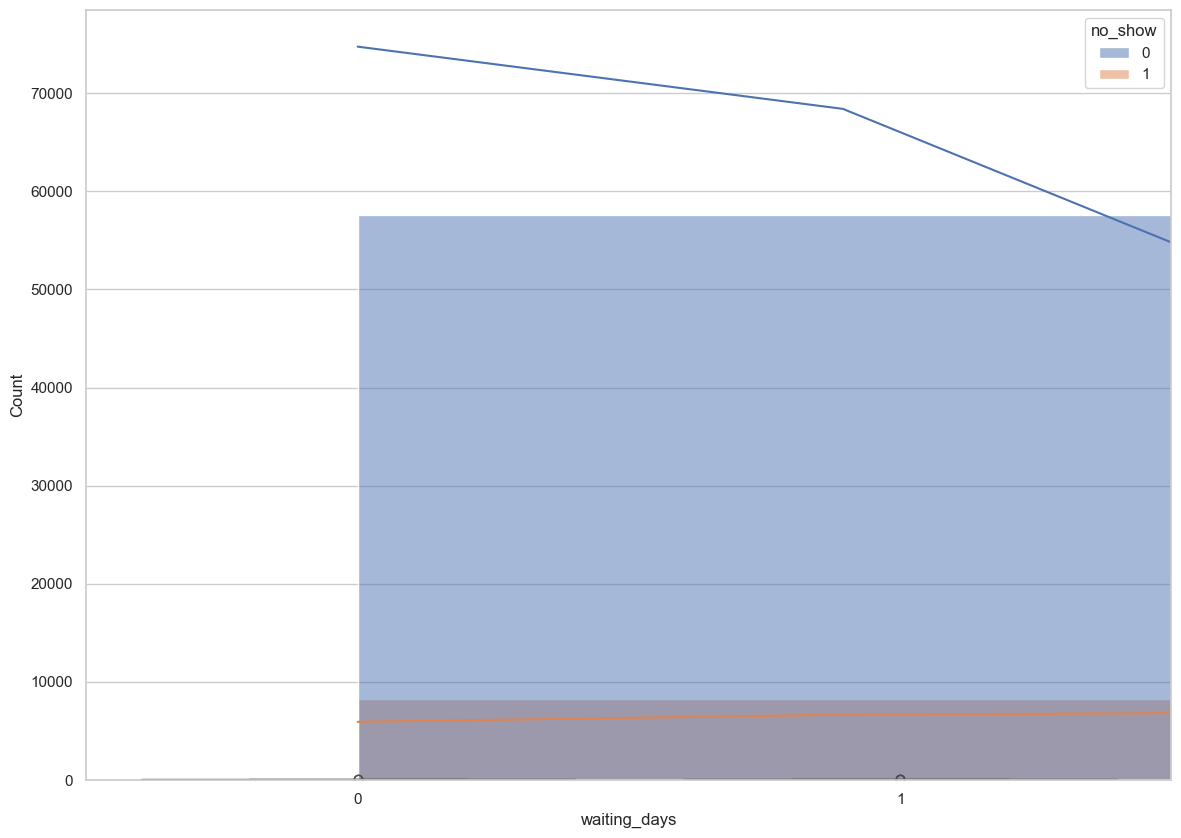

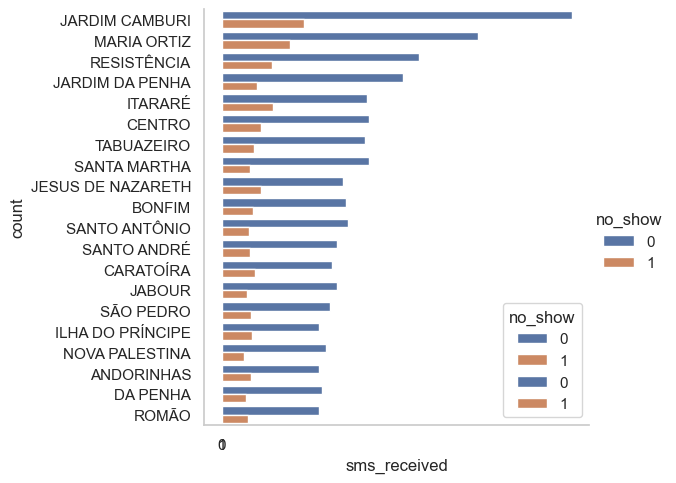

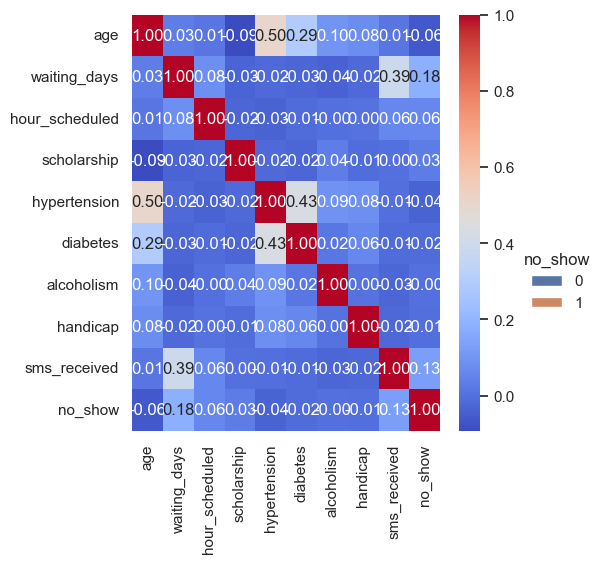

In [9]:
# No-show rate overall
sns.countplot(x='no_show', data=df)
plt.title("Class Distribution (0 = Show, 1 = No-Show)")
plt.show()

# Key plots
plt.figure(figsize=(14,10))

# 1. Waiting days
sns.histplot(data=df, x='waiting_days', hue='no_show', bins=30, kde=True)
plt.xlim(0, 100)

# 2. Age vs no-show
sns.boxplot(x='no_show', y='age', data=df)

# 3. SMS received
sns.catplot(x='sms_received', hue='no_show', kind='count', data=df)

# 4. Neighbourhood (top 20)
top_neigh = df['neighbourhood'].value_counts().head(20).index
sns.countplot(y='neighbourhood', hue='no_show', 
              data=df[df['neighbourhood'].isin(top_neigh)], 
              order=top_neigh)

# 5. Day of week
sns.catplot(x='day_of_week', hue='no_show', kind='count', 
            data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'])

# Correlation heatmap (numeric features)
numeric_cols = ['age', 'waiting_days', 'hour_scheduled', 'scholarship', 'hypertension',
                'diabetes', 'alcoholism', 'handicap', 'sms_received', 'no_show']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')

In [10]:
# One-hot encode categoricals
df = pd.get_dummies(df, columns=['gender', 'day_of_week'], drop_first=True)

# Drop columns we won't use
drop_cols = ['patient_id', 'appointment_id', 'scheduled_day', 'appointment_day', 'neighbourhood', 'handicap']  # handicap has very few >1
X = df.drop(['no_show'] + drop_cols, axis=1)
y = df['no_show']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


=== Logistic ===
              precision    recall  f1-score   support

           0       0.87      0.69      0.77     17642
           1       0.32      0.58      0.41      4464

    accuracy                           0.66     22106
   macro avg       0.59      0.63      0.59     22106
weighted avg       0.76      0.66      0.69     22106

AUC-ROC: 0.6654717859770936


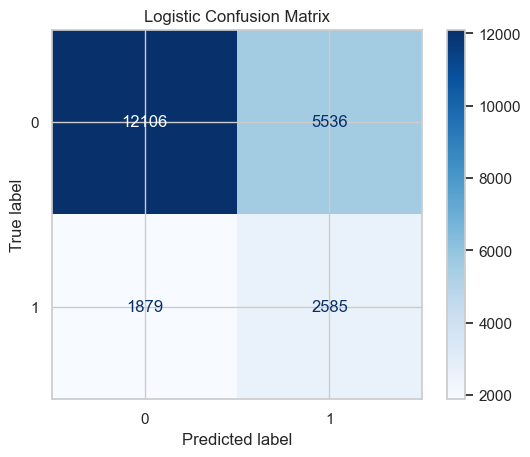


=== RandomForest ===
              precision    recall  f1-score   support

           0       0.82      0.89      0.85     17642
           1       0.33      0.22      0.26      4464

    accuracy                           0.75     22106
   macro avg       0.57      0.55      0.56     22106
weighted avg       0.72      0.75      0.73     22106

AUC-ROC: 0.6632944902986885


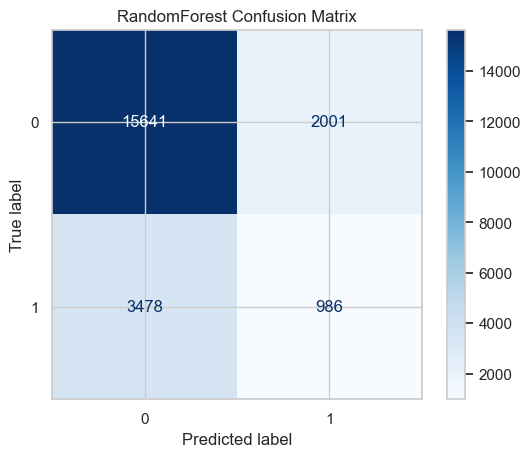


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.91      0.59      0.71     17642
           1       0.32      0.76      0.45      4464

    accuracy                           0.62     22106
   macro avg       0.61      0.67      0.58     22106
weighted avg       0.79      0.62      0.66     22106

AUC-ROC: 0.7243738556755445


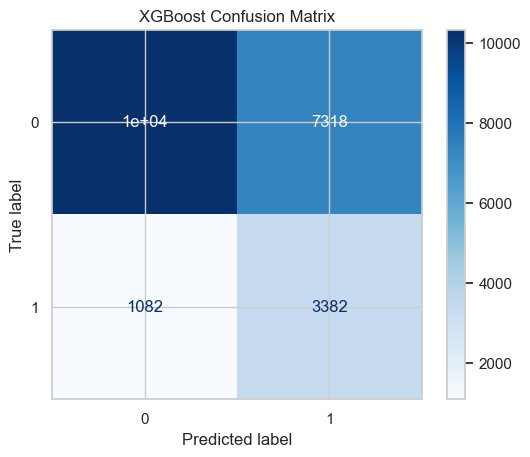

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

models = {
    'Logistic': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=4, random_state=42, eval_metric='auc')  # ~80/20 → weight ≈4
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    print("AUC-ROC:", roc_auc_score(y_test, y_prob))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

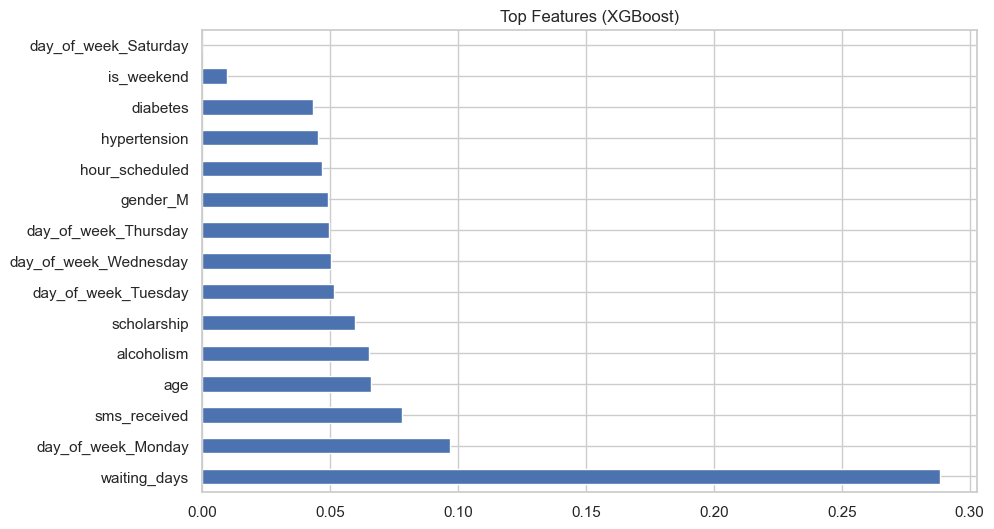

ModuleNotFoundError: No module named 'shap'

In [12]:
# XGBoost feature importance
importances = pd.Series(models['XGBoost'].feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(10,6))
plt.title("Top Features (XGBoost)")
plt.show()

# Optional: SHAP (install if needed: pip install shap)
import shap
explainer = shap.TreeExplainer(models['XGBoost'])
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [13]:
import sys
print(sys.executable)
print(sys.path[:3])  # first few entries usually show the env path

c:\Users\altus\anaconda3\envs\no-show\python.exe
['c:\\Users\\altus\\anaconda3\\envs\\no-show\\python310.zip', 'c:\\Users\\altus\\anaconda3\\envs\\no-show\\DLLs', 'c:\\Users\\altus\\anaconda3\\envs\\no-show\\lib']
